# XGBoost Baseline (Raw Features Only) - PS-S06E08

This notebook implements an XGBoost baseline for **Playground Series – Season 6, Episode 8: Predicting Smartphone Addiction**.

We employ Stratified 5-Fold cross-validation, multi-seed training, and hyperparameter tuning with an SQLite-backed Optuna database.

**Key diagnostic**: This run uses **only the 12 original raw features** (with categorical encoding) to benchmark clean, untampered performance against engineered feature sets.

## 1. Setup & Imports

In [1]:
import os
import gc
import sys
import json
import math
import time
import random
import warnings
from pathlib import Path

# --- Third-party
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from ps_s06e08_experiment_setup import ExperimentSetup
from ps_s06e08_feature_engineering import FeatureFactory
from ps_s06e08_model_visualizer import ModelVisualizer

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
setup = ExperimentSetup(
    model_name='XGBoost',
    use_gpu=True,  # Set to True on GPU-enabled environments
    perform_rfe=False,
    perform_optuna_tuning=True
)

seed = setup.set_seeds()
setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'addicted_label'

Random seed set to: 10301
Warnings suppressed.


## 2. Load Datasets

In [3]:
training_df = setup.read_dataset('training')
train_ids = training_df['id'].copy()

test_df = setup.read_dataset('test')
test_ids = test_df['id'].copy()

TRAINING DATASET

   id    age  daily_screen_time_hours  social_media_hours  gaming_hours  \
0   0 24.000                      NaN               1.830         1.590   
1   1 19.000                    5.970               1.080           NaN   
2   2 18.000                    5.090                 NaN           NaN   
3   3 21.000                    6.420               1.260         1.420   
4   4 26.000                   11.200               1.870         2.810   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0             2.110        7.460                122.000             38.000   
1             3.030        8.220                 76.000             19.000   
2               NaN        6.250                134.000             60.000   
3             3.360        8.850                112.000             94.000   
4             1.950        5.250                    NaN                NaN   

   weekend_screen_time  gender stress_level academic_work_impa

## 3. Feature Engineering

In [4]:
fe_strategies = [
    'encoding',
    'screen_time_ratios',
    'sleep_stress',
    'risk_score',
    'missing_flags',
]

print('Performing feature engineering (raw features only)...')
factory = FeatureFactory(
    strategies=fe_strategies,
    impute_strategy='median_mode',
    target=TARGET,
    verbose=True
)

y = training_df[TARGET].copy()

X = factory.fit_transform(training_df)
X_test = factory.transform(test_df)

print(f'Train features shape: {X.shape}')
print(f'Test features shape: {X_test.shape}')

Performing feature engineering (raw features only)...
  -> Fitting DataFrame...
Applying FeatureFactory with strategies: encoding, screen_time_ratios, sleep_stress, risk_score, missing_flags, numeric_expansion, age_benchmarks, behavioral_indices
  -> Imputing missing values using learned medians and modes...
  -> Adding missing flags...
  -> Encoding categorical variables...
  -> Adding screen time ratio features...
  -> Adding sleep_stress interaction features...
  -> Adding lifestyle risk score features...
  -> Adding age benchmark features...
  -> Adding behavioral indices...
  -> Adding numeric expansion features...
Applying FeatureFactory with strategies: encoding, screen_time_ratios, sleep_stress, risk_score, missing_flags, numeric_expansion, age_benchmarks, behavioral_indices
  -> Imputing missing values using learned medians and modes...
  -> Adding missing flags...
  -> Encoding categorical variables...
  -> Adding screen time ratio features...
  -> Adding sleep_stress interac

## 4. SQLite-Backed Optuna Optimization

Tunes model hyperparameters over a 5-fold CV split, caching trials dynamically in an SQLite database.

In [5]:
skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
fold_cache = []
for tr_idx, val_idx in skf_cv.split(X, y):
    fold_cache.append((tr_idx, val_idx))

def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'device': 'cuda' if setup.use_gpu() else 'cpu',
        'enable_categorical': True,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.30, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 100.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-8, 10.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': seed
    }
    
    oof_preds = np.full(len(y), -1.0, dtype=float)
    
    for fold, (tr_idx, val_idx) in enumerate(fold_cache):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        dtrain = xgb.DMatrix(X_tr, label=y_tr, enable_categorical=True, feature_names=list(X.columns))
        dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True, feature_names=list(X.columns))
        
        model = xgb.train(
            params,
            dtrain,
            num_boost_round=1000,
            evals=[(dval, 'val')],
            early_stopping_rounds=50,
            verbose_eval=False
        )
        
        preds = model.predict(dval, iteration_range=(0, model.best_iteration + 1))
        oof_preds[val_idx] = preds
        fold_score = roc_auc_score(y_val, preds)
        
        trial.report(fold_score, step=fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    filled_mask = oof_preds >= 0
    return roc_auc_score(y[filled_mask], oof_preds[filled_mask])

Loaded 8 parameters from optuna_params_xgb.json
Starting XGBoost SQLite Optuna Optimization (raw features)...


[I 2026-08-20 17:03:07,201] A new study created in RDB with name: xgb_raw_features_optuna_v3


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-08-20 17:03:52,254] Trial 0 finished with value: 0.9635689583490341 and parameters: {'learning_rate': 0.12473680642762926, 'max_depth': 5, 'subsample': 0.9565080583464127, 'colsample_bytree': 0.8514175221038868, 'min_child_weight': 4.144833730158134, 'gamma': 0.07624411838104503, 'reg_alpha': 9.438506245769279, 'reg_lambda': 0.009620314557537176}. Best is trial 0 with value: 0.9635689583490341.
[I 2026-08-20 17:04:41,035] Trial 1 finished with value: 0.9628056740123918 and parameters: {'learning_rate': 0.05722643470193996, 'max_depth': 6, 'subsample': 0.7985399433116422, 'colsample_bytree': 0.7103815135227967, 'min_child_weight': 11.17359337275724, 'gamma': 0.020308015338450527, 'reg_alpha': 1.4733188146848053e-08, 'reg_lambda': 0.13070193351156675}. Best is trial 0 with value: 0.9635689583490341.
[I 2026-08-20 17:05:27,839] Trial 2 finished with value: 0.963378022275114 and parameters: {'learning_rate': 0.08734115277021946, 'max_depth': 6, 'subsample': 0.7567356900014799, 'col

100%|██████████| 1.78k/1.78k [00:00<00:00, 4.72MB/s]


...

Upload successful: optuna_params_catboost.json (313B)
Starting upload for file optuna_params_xgb.json


100%|██████████| 290/290 [00:00<00:00, 530B/s]  


Upload successful: optuna_params_xgb.json (290B)
Starting upload for file selected_features_xgb.json


100%|██████████| 1.11k/1.11k [00:00<00:00, 1.29kB/s]


Upload successful: selected_features_xgb.json (1KB)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/stephentarter/ps-s06e08-artifacts
Kaggle artifacts dataset upload completed successfully!


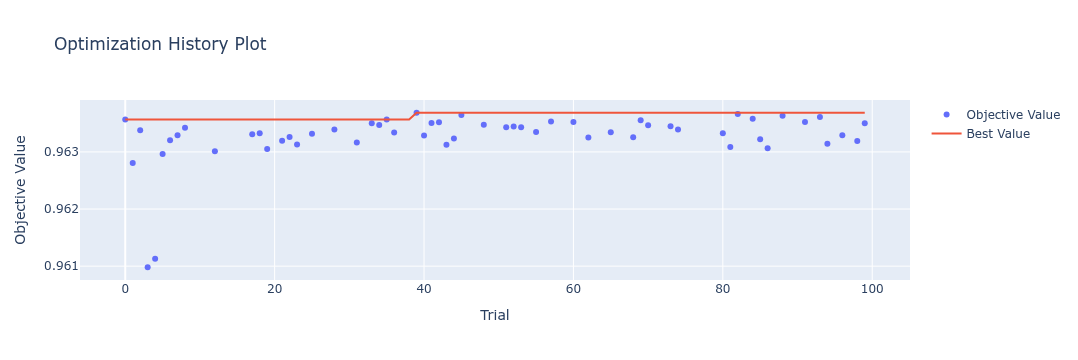

In [6]:
optuna_filename = 'optuna_params_xgb.json'
best_params = setup.load_optuna_params(optuna_filename)

if setup.perform_optuna_tuning() or len(best_params) == 0:
    print("Starting XGBoost SQLite Optuna Optimization (raw features)...")
    
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=3,
        interval_steps=1
    )
    
    study = optuna.create_study(
        storage='sqlite:///xgb_study_v3.db',
        load_if_exists=True,
        direction='maximize',
        study_name='xgb_raw_features_optuna_v3',
        pruner=pruner,
        sampler=optuna.samplers.TPESampler(
            seed=seed,
            n_startup_trials=5,
            multivariate=True
        )
    )
    
    study.optimize(objective, n_trials=100, timeout=7200, show_progress_bar=True)
    best_params = study.best_params
    print(f'Best score: {study.best_value:.5f}')
    print("Best params found:", best_params)
    setup.save_optuna_params(optuna_filename, best_params)
    setup.upload_artifact(optuna_filename)

    fig = optuna.visualization.plot_optimization_history(study)
    fig.show()
else:
    print("Using loaded parameters:", best_params)

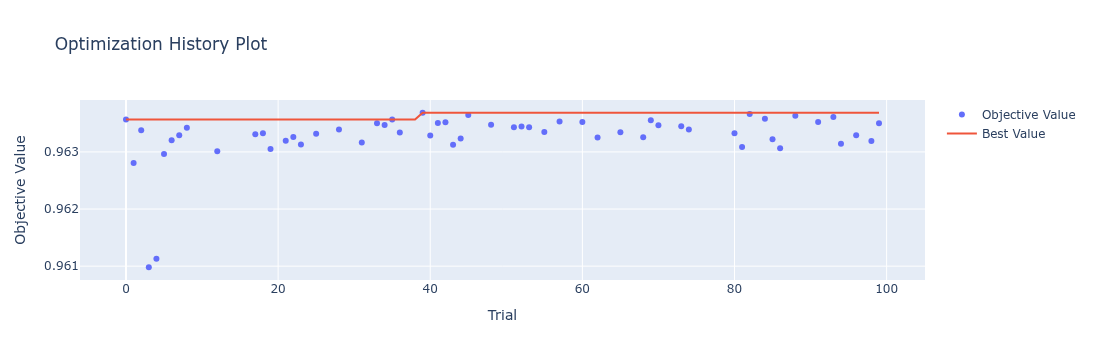

In [7]:
try:
    fig = optuna.visualization.plot_optimization_history(study)
    fig.show()
except NameError:
    print("Optuna wasn't run")

## 5. Model Training & Multi-Seed Blending

Trains the final seed-averaged models on the 12 raw features.

In [8]:
seeds = setup.seed()

# Track multi-class style probabilities: column 0 = prob(0), column 1 = prob(1)
oof_probs = np.zeros((len(X), 2))
test_probs = np.zeros((len(X_test), 2))
filled_mask = np.zeros(len(X), dtype=bool)

models = []
eval_results = []

for s_idx, current_seed in enumerate(seeds):
    print(f"\n================ SEED RUN {s_idx + 1}/{len(seeds)}: seed={current_seed} ================")
    
    xgb_params = {
        **best_params,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'device': 'cuda' if setup.use_gpu() else 'cpu',
        'enable_categorical': True,
        'random_state': current_seed
    }
    if 'max_depth' not in xgb_params:
        xgb_params['max_depth'] = 0
        
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=current_seed)
    
    oof_probs_seed = np.zeros((len(X), 2))
    test_probs_seed = np.zeros((len(X_test), 2))
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        dtrain = xgb.DMatrix(X_tr, label=y_tr, enable_categorical=True, feature_names=list(X.columns))
        dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True, feature_names=list(X.columns))
        dtest = xgb.DMatrix(X_test, enable_categorical=True, feature_names=list(X.columns))
        
        evals_result = {}
        model = xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=3000,
            evals=[(dtrain, 'train'), (dval, 'val')],
            early_stopping_rounds=50,
            evals_result=evals_result,
            verbose_eval=False
        )
        
        # Predict probabilities
        val_preds = model.predict(dval, iteration_range=(0, model.best_iteration + 1))
        oof_probs_seed[val_idx, 1] = val_preds
        oof_probs_seed[val_idx, 0] = 1.0 - val_preds
        filled_mask[val_idx] = True
        
        test_preds = model.predict(dtest, iteration_range=(0, model.best_iteration + 1))
        test_probs_seed[:, 1] += test_preds / 5.0
        test_probs_seed[:, 0] += (1.0 - test_preds) / 5.0
        
        fold_score = roc_auc_score(y_val, val_preds)
        n_trees = model.num_boosted_rounds()
        print(f"  Fold {fold+1} ROC AUC: {fold_score:.6f} (trees={n_trees})")
        
        models.append(model)
        eval_results.append(evals_result)
        
    seed_score = roc_auc_score(y, oof_probs_seed[:, 1])
    print(f"--- Seed {current_seed} CV ROC AUC: {seed_score:.6f} ---")
    
    oof_probs += oof_probs_seed / len(seeds)
    test_probs += test_probs_seed / len(seeds)

overall_score = roc_auc_score(y[filled_mask], oof_probs[filled_mask, 1])
print("\n" + "="*60)
print(f"Seed-Averaged CV ROC AUC: {overall_score:.6f}")
print("="*60)


================ SEED RUN 1/5: seed=10301 ================
  Fold 1 ROC AUC: 0.963188 (trees=1074)
  Fold 2 ROC AUC: 0.963789 (trees=1122)
  Fold 3 ROC AUC: 0.964091 (trees=1022)
  Fold 4 ROC AUC: 0.963920 (trees=1194)
  Fold 5 ROC AUC: 0.963530 (trees=1004)
--- Seed 10301 CV ROC AUC: 0.963704 ---

================ SEED RUN 2/5: seed=42 ================
  Fold 1 ROC AUC: 0.962955 (trees=1034)
  Fold 2 ROC AUC: 0.963786 (trees=1088)
  Fold 3 ROC AUC: 0.963795 (trees=953)
  Fold 4 ROC AUC: 0.964744 (trees=1262)
  Fold 5 ROC AUC: 0.963401 (trees=1210)
--- Seed 42 CV ROC AUC: 0.963737 ---

================ SEED RUN 3/5: seed=2026 ================
  Fold 1 ROC AUC: 0.962991 (trees=1149)
  Fold 2 ROC AUC: 0.964458 (trees=1136)
  Fold 3 ROC AUC: 0.964508 (trees=1191)
  Fold 4 ROC AUC: 0.963620 (trees=1031)
  Fold 5 ROC AUC: 0.963011 (trees=1180)
--- Seed 2026 CV ROC AUC: 0.963715 ---

================ SEED RUN 4/5: seed=777 ================
  Fold 1 ROC AUC: 0.964151 (trees=1125)
  Fold 2 RO

## 6. Performance Visualization

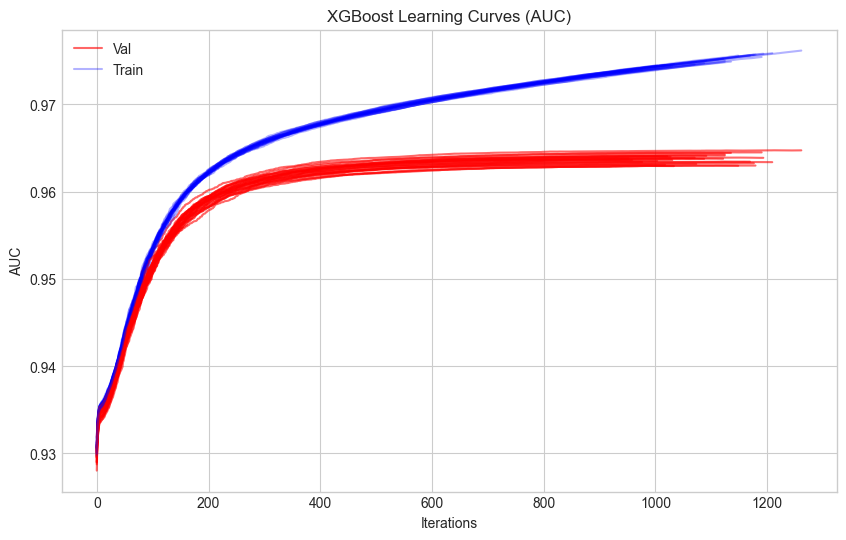

In [9]:
mviz = ModelVisualizer(model_name='XGBoost')

# Map learning metrics to ModelVisualizer expectations
adjusted_evals = []
for res in eval_results:
    adjusted_evals.append({
        'validation_0': res['val'],
        'validation_1': res['train']
    })

mviz.plot_learning_curves(adjusted_evals, metric='auc')

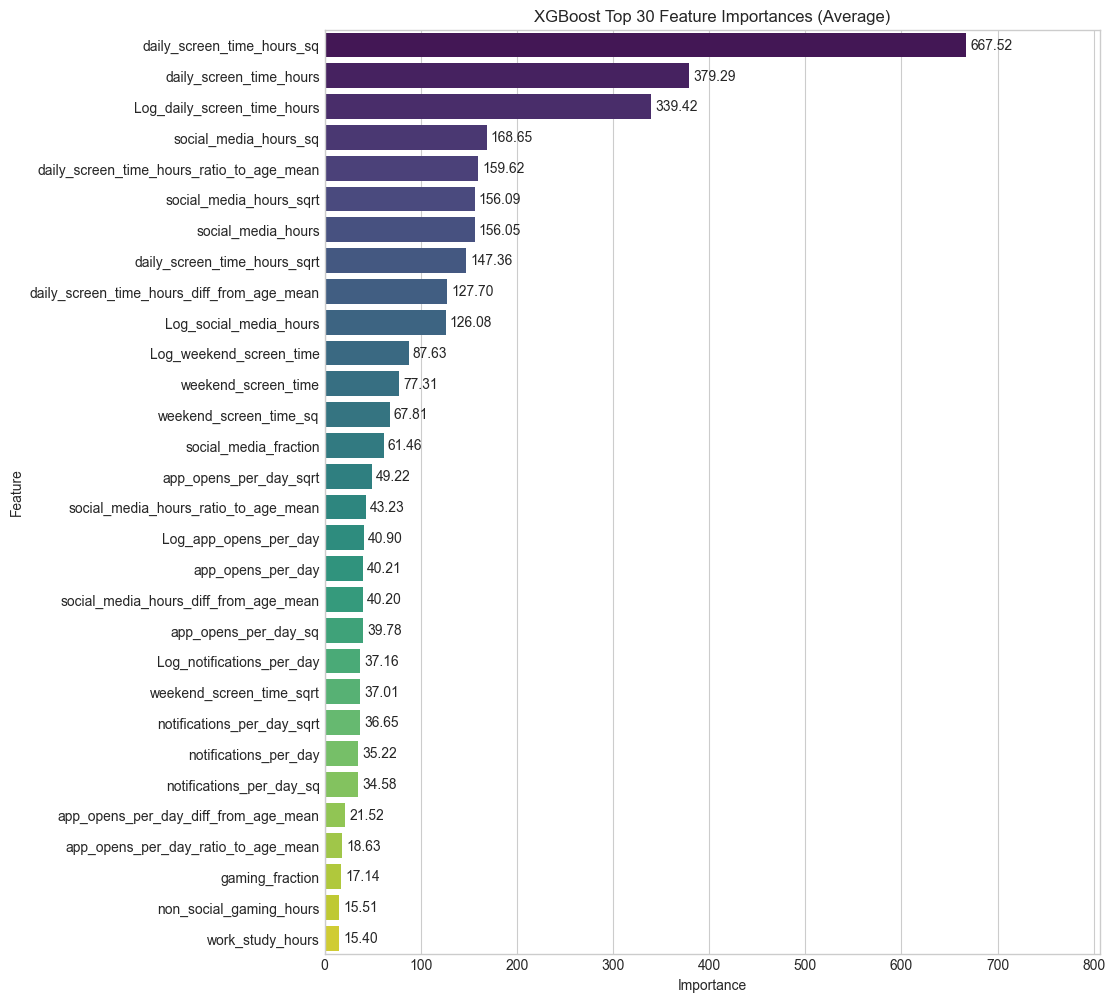

In [10]:
mviz.plot_feature_importance(models, show_values=True)

<Figure size 800x600 with 0 Axes>

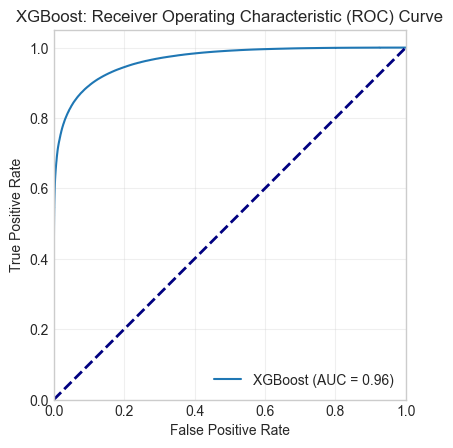

In [11]:
mviz.plot_roc_curve(y_true=y[filled_mask], y_score=oof_probs[filled_mask, 1])

Confusion matrix, without normalization


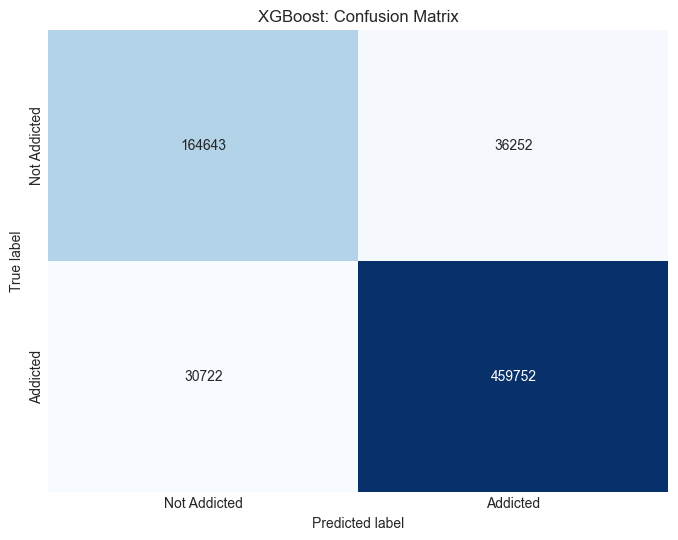

In [12]:
y_pred_class = (oof_probs[:, 1] > 0.5).astype(int)
mviz.plot_confusion_matrix(
    y_true=y[filled_mask],
    y_pred=y_pred_class[filled_mask],
    classes=['Not Addicted', 'Addicted']
)

## 7. Export Submission & Predictions

In [13]:
submission_df = setup.read_dataset('submission')
submission_df['addicted_label'] = test_probs[:, 1]
submission_df.to_csv('submission.csv', index=False)
print("Saved submission.csv successfully!")

Saved submission.csv successfully!


In [14]:
setup.save_probabilities('xgb', oof_probs, train_ids, y, filled_mask, test_probs, test_ids)

Saved for ensembling:
 - predictions/xgb_oof_probs.csv
 - predictions/xgb_test_probs.csv
